Dataset shape: (284807, 31)

FEATURE-LEVEL PSI

Top features by Train → Test PSI:
Feature  Train_vs_Validation_PSI Train_vs_Validation_Status  Train_vs_Test_PSI Train_vs_Test_Status
   Time                12.433665          Significant Drift          12.433665    Significant Drift
     V1                 0.936189          Significant Drift           1.013990    Significant Drift
     V3                 0.776740          Significant Drift           0.750466    Significant Drift
    V28                 0.530602          Significant Drift           0.531931    Significant Drift
    V11                 0.327613          Significant Drift           0.339372    Significant Drift
    V25                 0.220032             Moderate Drift           0.286270    Significant Drift
    V12                 0.191477             Moderate Drift           0.217529       Moderate Drift
    V15                 0.206691             Moderate Drift           0.217404       Moderate Drift
     V5           

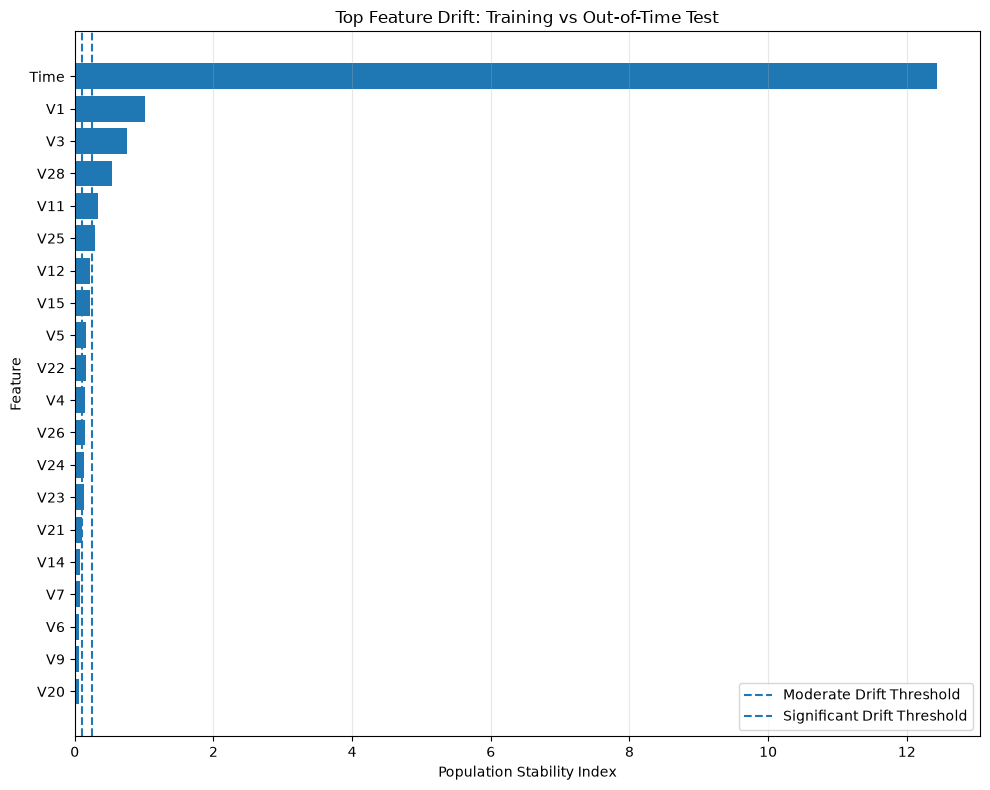


FROZEN MODEL

Model: Class Weighted XGBoost
Threshold: 0.56

Training frozen model...
Training complete.

MODEL SCORE DRIFT

Train → Validation score PSI: 0.038259
Status: Stable

Train → Test score PSI: 0.08652
Status: Stable


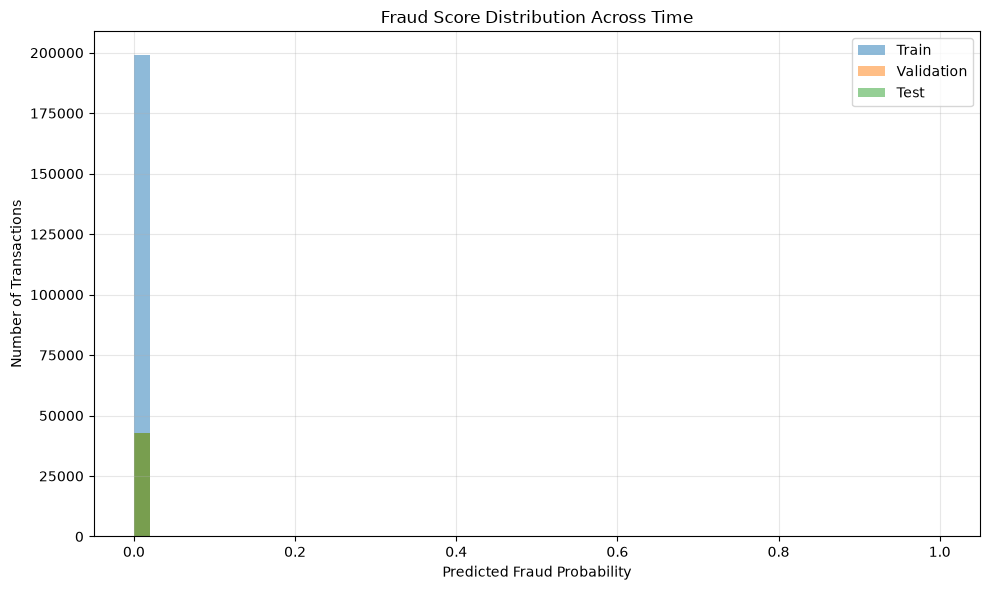


ALERT RATE STABILITY
   Dataset  Transactions  Alerts  Alert_Rate
     Train        199364     384    0.001926
Validation         42721      44    0.001030
      Test         42722      45    0.001053

DRIFT FLAGS

Significant drift features: 6
Moderate drift features: 9

Significant drift:
Feature  Train_vs_Test_PSI
   Time          12.433665
     V1           1.013990
     V3           0.750466
    V28           0.531931
    V11           0.339372
    V25           0.286270

OVERALL MONITORING STATUS

Status: INVESTIGATE DRIFT

PHASE 11 COMPLETE

Generated files:
✓ feature_psi_analysis.csv
✓ feature_psi_top20.png
✓ fraud_score_distribution_drift.png
✓ alert_rate_stability.csv
✓ phase11_drift_summary.json


Phase 11 evaluates whether the feature and model-score distributions remain stable out-of-time.

Next: Phase 12 — Final Banking-Grade Pipeline, README and Project Packaging


In [1]:
# ============================================================
# PHASE 11 — PSI / OUT-OF-TIME STABILITY & DRIFT MONITORING
# Credit Card Fraud Decision Engine
# ============================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE


# ============================================================
# 1. PATHS
# ============================================================

DATA_PATH = Path("../data/creditcard.csv")
REPORTS_PATH = Path("../reports")

REPORTS_PATH.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. LOAD DATA
# ============================================================

df = pd.read_csv(
    DATA_PATH
)

df = df.sort_values(
    "Time"
).reset_index(
    drop=True
)

print(
    "Dataset shape:",
    df.shape
)


# ============================================================
# 3. TEMPORAL SPLIT
# ============================================================

n = len(df)

train_end = int(
    n * 0.70
)

validation_end = int(
    n * 0.85
)

train = df.iloc[
    :train_end
].copy()

validation = df.iloc[
    train_end:validation_end
].copy()

test = df.iloc[
    validation_end:
].copy()


X_train = train.drop(
    columns=["Class"]
)

y_train = train["Class"]


X_validation = validation.drop(
    columns=["Class"]
)

y_validation = validation["Class"]


X_test = test.drop(
    columns=["Class"]
)

y_test = test["Class"]


# ============================================================
# 4. PSI FUNCTION
# ============================================================

def calculate_psi(
    expected,
    actual,
    bins=10
):
    """
    Calculate Population Stability Index.

    expected = reference/training distribution
    actual   = later/monitoring distribution

    PSI:
        sum((actual% - expected%) *
            ln(actual% / expected%))
    """

    expected = np.asarray(
        expected,
        dtype=float
    )

    actual = np.asarray(
        actual,
        dtype=float
    )

    # Remove NaN / infinite values
    expected = expected[
        np.isfinite(expected)
    ]

    actual = actual[
        np.isfinite(actual)
    ]

    if len(expected) == 0 or len(actual) == 0:

        return np.nan

    # --------------------------------------------------------
    # Build bins using ONLY the reference distribution
    # --------------------------------------------------------

    quantiles = np.linspace(
        0,
        1,
        bins + 1
    )

    breakpoints = np.quantile(
        expected,
        quantiles
    )

    breakpoints = np.unique(
        breakpoints
    )

    # Constant feature
    if len(breakpoints) <= 2:

        expected_pct = np.array([1.0])
        actual_pct = np.array([1.0])

    else:

        # Remove duplicate endpoints
        breakpoints[0] = -np.inf
        breakpoints[-1] = np.inf

        expected_counts, _ = np.histogram(
            expected,
            bins=breakpoints
        )

        actual_counts, _ = np.histogram(
            actual,
            bins=breakpoints
        )

        expected_pct = (
            expected_counts /
            len(expected)
        )

        actual_pct = (
            actual_counts /
            len(actual)
        )

    # --------------------------------------------------------
    # Avoid log(0)
    # --------------------------------------------------------

    epsilon = 1e-6

    expected_pct = np.clip(
        expected_pct,
        epsilon,
        None
    )

    actual_pct = np.clip(
        actual_pct,
        epsilon,
        None
    )

    psi = np.sum(
        (
            actual_pct -
            expected_pct
        )
        *
        np.log(
            actual_pct /
            expected_pct
        )
    )

    return float(
        psi
    )


# ============================================================
# 5. PSI INTERPRETATION
# ============================================================

def interpret_psi(
    psi
):

    if pd.isna(psi):

        return "Unavailable"

    elif psi < 0.10:

        return "Stable"

    elif psi < 0.25:

        return "Moderate Drift"

    else:

        return "Significant Drift"


# ============================================================
# 6. FEATURE-LEVEL PSI
# ============================================================

print("\n" + "=" * 70)
print("FEATURE-LEVEL PSI")
print("=" * 70)


psi_records = []


for feature in X_train.columns:

    train_values = (
        X_train[feature]
        .values
    )

    validation_values = (
        X_validation[feature]
        .values
    )

    test_values = (
        X_test[feature]
        .values
    )


    validation_psi = calculate_psi(
        train_values,
        validation_values
    )

    test_psi = calculate_psi(
        train_values,
        test_values
    )


    psi_records.append({

        "Feature":
            feature,

        "Train_vs_Validation_PSI":
            validation_psi,

        "Train_vs_Validation_Status":
            interpret_psi(
                validation_psi
            ),

        "Train_vs_Test_PSI":
            test_psi,

        "Train_vs_Test_Status":
            interpret_psi(
                test_psi
            )
    })


psi_df = pd.DataFrame(
    psi_records
)


psi_df = psi_df.sort_values(
    "Train_vs_Test_PSI",
    ascending=False
).reset_index(
    drop=True
)


# ============================================================
# 7. DISPLAY TOP DRIFTED FEATURES
# ============================================================

print(
    "\nTop features by Train → Test PSI:"
)

print(
    psi_df.head(20).to_string(
        index=False
    )
)


# ============================================================
# 8. SAVE FEATURE PSI
# ============================================================

psi_df.to_csv(

    REPORTS_PATH /
    "feature_psi_analysis.csv",

    index=False
)


# ============================================================
# 9. PSI SUMMARY
# ============================================================

def psi_summary(
    values
):

    return {

        "Stable":
            int(
                (values < 0.10)
                .sum()
            ),

        "Moderate_Drift":
            int(
                (
                    (values >= 0.10)
                    &
                    (values < 0.25)
                )
                .sum()
            ),

        "Significant_Drift":
            int(
                (values >= 0.25)
                .sum()
            )
    }


validation_summary = psi_summary(
    psi_df[
        "Train_vs_Validation_PSI"
    ]
)

test_summary = psi_summary(
    psi_df[
        "Train_vs_Test_PSI"
    ]
)


print("\n" + "=" * 70)
print("PSI SUMMARY")
print("=" * 70)


print("\nTrain → Validation")

print(
    validation_summary
)


print("\nTrain → Test")

print(
    test_summary
)


# ============================================================
# 10. TOP 20 PSI BAR CHART
# ============================================================

top_psi = (
    psi_df
    .head(20)
    .sort_values(
        "Train_vs_Test_PSI"
    )
)


plt.figure(
    figsize=(10, 8)
)

plt.barh(

    top_psi["Feature"],

    top_psi[
        "Train_vs_Test_PSI"
    ]
)

plt.axvline(
    0.10,
    linestyle="--",
    label="Moderate Drift Threshold"
)

plt.axvline(
    0.25,
    linestyle="--",
    label="Significant Drift Threshold"
)

plt.xlabel(
    "Population Stability Index"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Top Feature Drift: Training vs Out-of-Time Test"
)

plt.legend()

plt.grid(
    axis="x",
    alpha=0.3
)

plt.tight_layout()

plt.savefig(

    REPORTS_PATH /
    "feature_psi_top20.png",

    dpi=200,

    bbox_inches="tight"
)

plt.show()


# ============================================================
# 11. REBUILD FINAL MODEL
#
# Use the frozen policy from Phase 9.
# ============================================================

policy_path = (
    REPORTS_PATH /
    "frozen_decision_policy.json"
)


if not policy_path.exists():

    raise FileNotFoundError(
        "frozen_decision_policy.json "
        "not found. Run Phase 9 first."
    )


with open(
    policy_path,
    "r"
) as f:

    policy = json.load(f)


selected_model_name = (
    policy["model"]
)

frozen_threshold = float(
    policy["threshold"]
)


print("\n" + "=" * 70)
print("FROZEN MODEL")
print("=" * 70)

print(
    "\nModel:",
    selected_model_name
)

print(
    "Threshold:",
    frozen_threshold
)


if selected_model_name == "SMOTE XGBoost":

    smote = SMOTE(
        sampling_strategy=1.0,
        random_state=42
    )

    X_train_model, y_train_model = (
        smote.fit_resample(
            X_train,
            y_train
        )
    )

    final_model = XGBClassifier(

        n_estimators=500,

        max_depth=6,

        learning_rate=0.05,

        subsample=0.8,

        colsample_bytree=0.8,

        objective="binary:logistic",

        eval_metric="aucpr",

        scale_pos_weight=1,

        tree_method="hist",

        random_state=42,

        n_jobs=-1
    )

else:

    negative_count = (
        y_train == 0
    ).sum()

    positive_count = (
        y_train == 1
    ).sum()

    scale_pos_weight = (
        negative_count /
        positive_count
    )

    X_train_model = X_train

    y_train_model = y_train

    final_model = XGBClassifier(

        n_estimators=500,

        max_depth=6,

        learning_rate=0.05,

        subsample=0.8,

        colsample_bytree=0.8,

        objective="binary:logistic",

        eval_metric="aucpr",

        scale_pos_weight=
            scale_pos_weight,

        tree_method="hist",

        random_state=42,

        n_jobs=-1
    )


print(
    "\nTraining frozen model..."
)

final_model.fit(
    X_train_model,
    y_train_model
)

print(
    "Training complete."
)


# ============================================================
# 12. MODEL SCORE DISTRIBUTIONS
# ============================================================

train_probability = (
    final_model.predict_proba(
        X_train
    )[:, 1]
)

validation_probability = (
    final_model.predict_proba(
        X_validation
    )[:, 1]
)

test_probability = (
    final_model.predict_proba(
        X_test
    )[:, 1]
)


# ============================================================
# 13. SCORE PSI
# ============================================================

score_validation_psi = calculate_psi(

    train_probability,

    validation_probability
)


score_test_psi = calculate_psi(

    train_probability,

    test_probability
)


print("\n" + "=" * 70)
print("MODEL SCORE DRIFT")
print("=" * 70)


print(
    "\nTrain → Validation score PSI:",
    round(
        score_validation_psi,
        6
    )
)

print(
    "Status:",
    interpret_psi(
        score_validation_psi
    )
)


print(
    "\nTrain → Test score PSI:",
    round(
        score_test_psi,
        6
    )
)

print(
    "Status:",
    interpret_psi(
        score_test_psi
    )
)


# ============================================================
# 14. SCORE DISTRIBUTION PLOT
# ============================================================

plt.figure(
    figsize=(10, 6)
)

plt.hist(

    train_probability,

    bins=50,

    alpha=0.5,

    label="Train"
)

plt.hist(

    validation_probability,

    bins=50,

    alpha=0.5,

    label="Validation"
)

plt.hist(

    test_probability,

    bins=50,

    alpha=0.5,

    label="Test"
)


plt.xlabel(
    "Predicted Fraud Probability"
)

plt.ylabel(
    "Number of Transactions"
)

plt.title(
    "Fraud Score Distribution Across Time"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.tight_layout()


plt.savefig(

    REPORTS_PATH /
    "fraud_score_distribution_drift.png",

    dpi=200,

    bbox_inches="tight"
)

plt.show()


# ============================================================
# 15. ALERT RATE STABILITY
# ============================================================

train_alerts = (
    train_probability >=
    frozen_threshold
)

validation_alerts = (
    validation_probability >=
    frozen_threshold
)

test_alerts = (
    test_probability >=
    frozen_threshold
)


alert_stability = pd.DataFrame({

    "Dataset": [
        "Train",
        "Validation",
        "Test"
    ],

    "Transactions": [

        len(
            train_probability
        ),

        len(
            validation_probability
        ),

        len(
            test_probability
        )
    ],

    "Alerts": [

        int(
            train_alerts.sum()
        ),

        int(
            validation_alerts.sum()
        ),

        int(
            test_alerts.sum()
        )
    ]
})


alert_stability[
    "Alert_Rate"
] = (
    alert_stability[
        "Alerts"
    ]
    /
    alert_stability[
        "Transactions"
    ]
)


print("\n" + "=" * 70)
print("ALERT RATE STABILITY")
print("=" * 70)

print(
    alert_stability.to_string(
        index=False
    )
)


alert_stability.to_csv(

    REPORTS_PATH /
    "alert_rate_stability.csv",

    index=False
)


# ============================================================
# 16. FEATURE DRIFT FLAGS
# ============================================================

significant_drift_features = (
    psi_df[
        psi_df[
            "Train_vs_Test_PSI"
        ] >= 0.25
    ]
)


moderate_drift_features = (
    psi_df[
        (
            psi_df[
                "Train_vs_Test_PSI"
            ] >= 0.10
        )
        &
        (
            psi_df[
                "Train_vs_Test_PSI"
            ] < 0.25
        )
    ]
)


print("\n" + "=" * 70)
print("DRIFT FLAGS")
print("=" * 70)


print(
    "\nSignificant drift features:",
    len(
        significant_drift_features
    )
)


print(
    "Moderate drift features:",
    len(
        moderate_drift_features
    )
)


if len(
    significant_drift_features
) > 0:

    print(
        "\nSignificant drift:"
    )

    print(
        significant_drift_features[
            [
                "Feature",
                "Train_vs_Test_PSI"
            ]
        ].to_string(
            index=False
        )
    )


# ============================================================
# 17. CREATE MONITORING STATUS
# ============================================================

if (

    score_test_psi < 0.10

    and

    len(
        significant_drift_features
    ) == 0
):

    overall_status = (
        "STABLE"
    )

elif (

    score_test_psi < 0.25

    and

    len(
        significant_drift_features
    ) <= 3
):

    overall_status = (
        "MONITOR"
    )

else:

    overall_status = (
        "INVESTIGATE DRIFT"
    )


print("\n" + "=" * 70)
print("OVERALL MONITORING STATUS")
print("=" * 70)

print(
    "\nStatus:",
    overall_status
)


# ============================================================
# 18. SAVE DRIFT SUMMARY
# ============================================================

drift_summary = {

    "reference_dataset":
        "Train",

    "monitoring_datasets":
        [
            "Validation",
            "Test"
        ],

    "feature_count":
        len(X_train.columns),

    "validation_feature_psi":
        validation_summary,

    "test_feature_psi":
        test_summary,

    "score_psi": {

        "train_vs_validation":
            score_validation_psi,

        "train_vs_test":
            score_test_psi
    },

    "significant_drift_feature_count":
        len(
            significant_drift_features
        ),

    "moderate_drift_feature_count":
        len(
            moderate_drift_features
        ),

    "overall_status":
        overall_status,

    "psi_thresholds": {

        "stable":
            "< 0.10",

        "moderate":
            "0.10 to < 0.25",

        "significant":
            ">= 0.25"
    }
}


with open(

    REPORTS_PATH /
    "phase11_drift_summary.json",

    "w"

) as f:

    json.dump(

        drift_summary,

        f,

        indent=4
    )


# ============================================================
# 19. FINAL FILE CHECK
# ============================================================

print("\n" + "=" * 70)
print("PHASE 11 COMPLETE")
print("=" * 70)


files_created = [

    "feature_psi_analysis.csv",

    "feature_psi_top20.png",

    "fraud_score_distribution_drift.png",

    "alert_rate_stability.csv",

    "phase11_drift_summary.json"
]


print(
    "\nGenerated files:"
)


for filename in files_created:

    path = (
        REPORTS_PATH /
        filename
    )

    if path.exists():

        print(
            "✓",
            filename
        )

    else:

        print(
            "—",
            filename,
            "(not generated)"
        )


print("\n")
print(
    "Phase 11 evaluates whether the feature "
    "and model-score distributions remain stable "
    "out-of-time."
)

print(
    "\nNext: Phase 12 — Final Banking-Grade "
    "Pipeline, README and Project Packaging"
)